In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


In [3]:
np.random.seed(42)

n_users = 2000

user_ids = [f"USER_{1000 + i}" for i in range(n_users)]
cohort_dates = pd.date_range(start="2026-07-01", end="2026-07-31", freq="D")

events_list = []

for u_id in user_ids:

    reg_date = np.random.choice(cohort_dates)

    events_list.append({'user_id': u_id, 'event_time': reg_date, 'event_type': '1_visit'})

    if np.random.rand() < 0.80:
        events_list.append({'user_id': u_id, 'event_time': reg_date + pd.Timedelta(minutes=np.random.randint(1, 10)), 'event_type': '2_product_view'})
        
        if np.random.rand() < 0.50:
            events_list.append({'user_id': u_id, 'event_time': reg_date + pd.Timedelta(minutes=np.random.randint(11, 30)), 'event_type': '3_add_to_cart'})

            if np.random.rand() < 0.60:
                events_list.append({'user_id': u_id, 'event_time': reg_date + pd.Timedelta(minutes=np.random.randint(31, 45)), 'event_type': '4_checkout'})

                if np.random.rand() < 0.75:
                    events_list.append({'user_id': u_id, 'event_time': reg_date + pd.Timedelta(minutes=np.random.randint(46, 60)), 'event_type': '5_payment_success'})


df_events = pd.DataFrame(events_list)

print(f"Всего событий сгенерированно: {len(df_events)}")
df_events.head(10)

Всего событий сгенерированно: 5305


,user_id,event_time,event_type
0,USER_1000,2026-07-07 00:00:00,1_visit
1,USER_1000,2026-07-07 00:08:00,2_product_view
2,USER_1001,2026-07-07 00:00:00,1_visit
3,USER_1001,2026-07-07 00:07:00,2_product_view
4,USER_1001,2026-07-07 00:14:00,3_add_to_cart
5,USER_1001,2026-07-07 00:33:00,4_checkout
6,USER_1001,2026-07-07 00:47:00,5_payment_success
7,USER_1002,2026-07-24 00:00:00,1_visit
8,USER_1003,2026-07-06 00:00:00,1_visit
9,USER_1003,2026-07-06 00:05:00,2_product_view


In [4]:
funnel_df = df_events.groupby('event_type')['user_id'].nunique().reset_index()

funnel_df.columns = ['event_type', 'user_count']

total_visitors = funnel_df.loc[0, 'user_count']
funnel_df['conversion_from_first_step_%'] = (funnel_df['user_count'] / total_visitors * 100).round(2)

funnel_df['previous_step_users'] = funnel_df['user_count'].shift(1)

funnel_df['previous_step_users'] = funnel_df['previous_step_users'].fillna(total_visitors)

funnel_df['step_to_step_cr_%'] = (funnel_df['user_count'] / funnel_df['previous_step_users'] * 100).round(2)

funnel_df = funnel_df.drop(columns=['previous_step_users'])

funnel_df

,event_type,user_count,conversion_from_first_step_%,step_to_step_cr_%
0,1_visit,2000,100.00,100.00
1,2_product_view,1616,80.80,80.80
2,3_add_to_cart,808,40.40,50.00
3,4_checkout,498,24.90,61.63
4,5_payment_success,383,19.15,76.91


C:\Users\User\AppData\Local\Temp\ipykernel_1844\3010013239.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


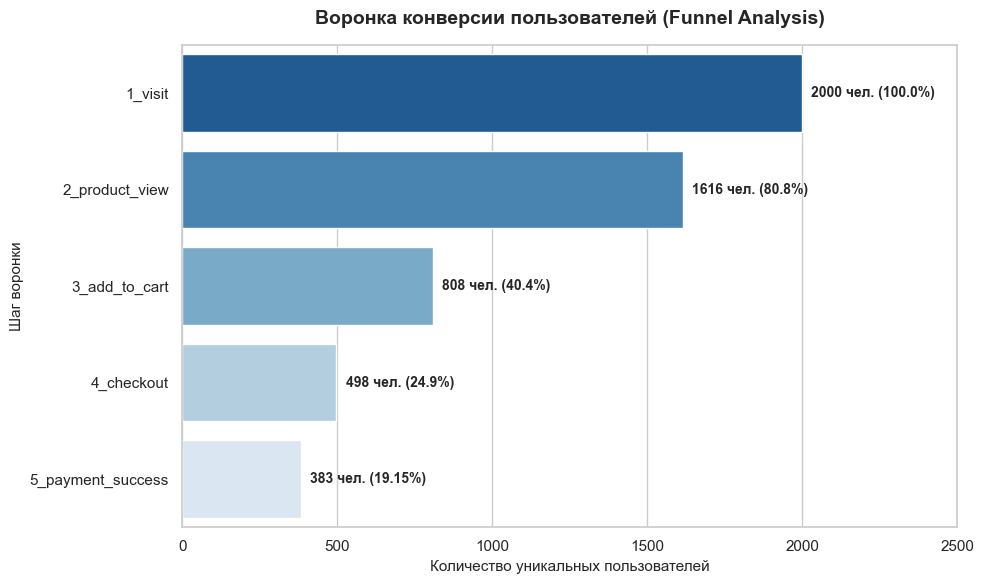

In [5]:

plt.close('all')

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Передаем ax=ax прямо в seaborn, чтобы он строил строго на нашей оси
sns.barplot(
    data=funnel_df, 
    x='user_count', 
    y='event_type', 
    palette='Blues_r',
    ax=ax,
)

ax.set_title('Воронка конверсии пользователей (Funnel Analysis)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Количество уникальных пользователей', fontsize=11)
ax.set_ylabel('Шаг воронки', fontsize=11)

for index, row in funnel_df.iterrows():
    text = f"{int(row['user_count'])} чел. ({row['conversion_from_first_step_%']}%)"
    ax.text(
        x=row['user_count'] + 30, 
        y=index, 
        s=text, 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

ax.set_xlim(0, funnel_df['user_count'].max() * 1.25)

plt.tight_layout()
plt.show()

In [6]:
np.random.seed(42)

user_first_visit = df_events.groupby('user_id')['event_time'].min().reset_index()
user_first_visit.columns = ['user_id', 'first_visit_time']

repeat_events = []

for _, row in user_first_visit.iterrows():
    u_id = row['user_id']
    first_date = row['first_visit_time']

    if np.random.rand() < 0.60:
        n_returns = np.random.randint(1, 5)
        for _ in range(n_returns):
            days_after = int(np.random.choice([1, 2, 3, 5, 7, 10, 14, 21, 28], p=[0.25, 0.18, 0.15, 0.12, 0.10, 0.08, 0.06, 0.04, 0.02]))
            return_time = first_date + pd.Timedelta(days=days_after)

            repeat_events.append({
                'user_id': u_id,
                'event_time': return_time,
                'event_type': 'repeat_visit'
            })

df_repeat = pd.DataFrame(repeat_events)
df_all_events = pd.concat([df_events, df_repeat], ignore_index=True)

print(f"Всего событий в журнале с учетом повторных визитов: {len(df_all_events)}")



Всего событий в журнале с учетом повторных визитов: 8366


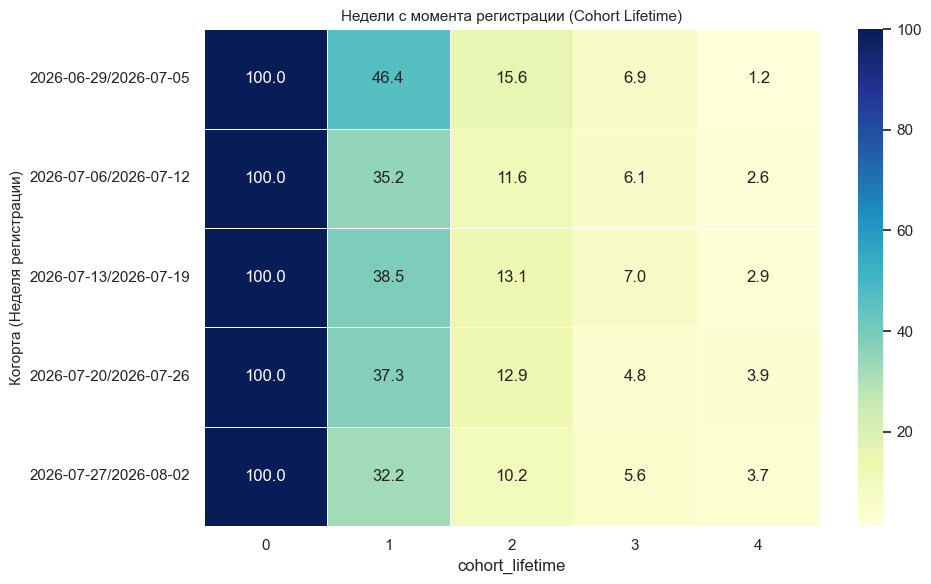

In [9]:
df_all_events['event_time'] = pd.to_datetime(df_all_events['event_time'])

user_cohorts = df_all_events.groupby('user_id')['event_time'].min().dt.to_period('W').reset_index()
user_cohorts.columns = ['user_id', 'cohort_week']

df_merged = pd.merge(df_all_events, user_cohorts, on='user_id')

df_merged['event_week'] = df_merged['event_time'].dt.to_period('W')

df_merged['cohort_lifetime'] = (df_merged['event_week'] - df_merged['cohort_week']).apply(lambda x: x.n)

cohort_pivot = df_merged.pivot_table(
    index='cohort_week',
    columns='cohort_lifetime',
    values='user_id',
    aggfunc='nunique'
)

cohort_sizes = cohort_pivot.iloc[:, 0]

retention_matrix = cohort_pivot.div(cohort_sizes, axis=0) * 100

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=ax
)

ax.set_title('Матрица удержания пользователей (Cohort Retention Rate %)', fontsize=14, fontweight='bold', pad=15)
ax.set_title('Недели с момента регистрации (Cohort Lifetime)', fontsize=11)
ax.set_ylabel('Когорта (Неделя регистрации)', fontsize=11)

plt.tight_layout()
plt.show()